# ============================================================
# CODVEDA INTERNSHIP | Level 1 | Task 2: EDA
# Dataset: Iris_Clean
# ============================================================

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
# Show all column
pd.set_option('display.max_columns', None)

In [4]:
# Load the iris dataset
df_iris_clean = pd.read_csv('iris_clean.csv')

In [12]:
# Add a divider line
print(f" {'=' *50}")
print("# CODVEDA INTERNSHIP | Level 1 | Task 2: EDA")
print("# Dataset: iris_clean.csv (output from Task 1)")
print(f"{'=' *50}")

# CODVEDA INTERNSHIP | Level 1 | Task 2: EDA
# Dataset: iris_clean.csv (output from Task 1)


In [13]:
# what the data looks like
# Describe the dataset
def df_summary(df):
    print("=" * 60)
    print("SUMMARY STATISTICS - ALL NUMERIC COLOUMN")
    print("=" * 60)
    display(df.describe().round(2))

    # To see more data in the dataframe
    print("\nTransposed df_iris_clean - easier to read:")
    display(df.describe().T.round(2))

df_summary(df_iris_clean)

SUMMARY STATISTICS - ALL NUMERIC COLOUMN


,sepal_length,sepal_width,petal_length,petal_width
count,147.00,147.00,147.00,147.00
mean,5.86,3.06,3.78,1.21
std,0.83,0.44,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.40,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



Transposed df_iris_clean - easier to read:


,count,mean,std,min,25%,50%,75%,max
sepal_length,147.0,5.86,0.83,4.3,5.1,5.8,6.4,7.9
sepal_width,147.0,3.06,0.44,2.0,2.8,3.0,3.3,4.4
petal_length,147.0,3.78,1.76,1.0,1.6,4.4,5.1,6.9
petal_width,147.0,1.21,0.76,0.1,0.3,1.3,1.8,2.5


In [14]:

def df_summary(df):
    print("=" * 60)
    print("SUMMARY STATISTICS - ALL NUMERIC COLOUMN")
    print("=" * 60)
    display(df.describe().round(2))

    # To see more data in the dataframe
    print("\nTransposed df_iris_clean - easier to read:")
    display(df.describe().T.round(2))

    # Average Values per category
    df_iris_clean.groupby('species').mean().round(2)
    

In [15]:
# Average Values per species
df_iris_clean.groupby('species').mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.60,2.98,5.56,2.03


LIST OF COLUMNS
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


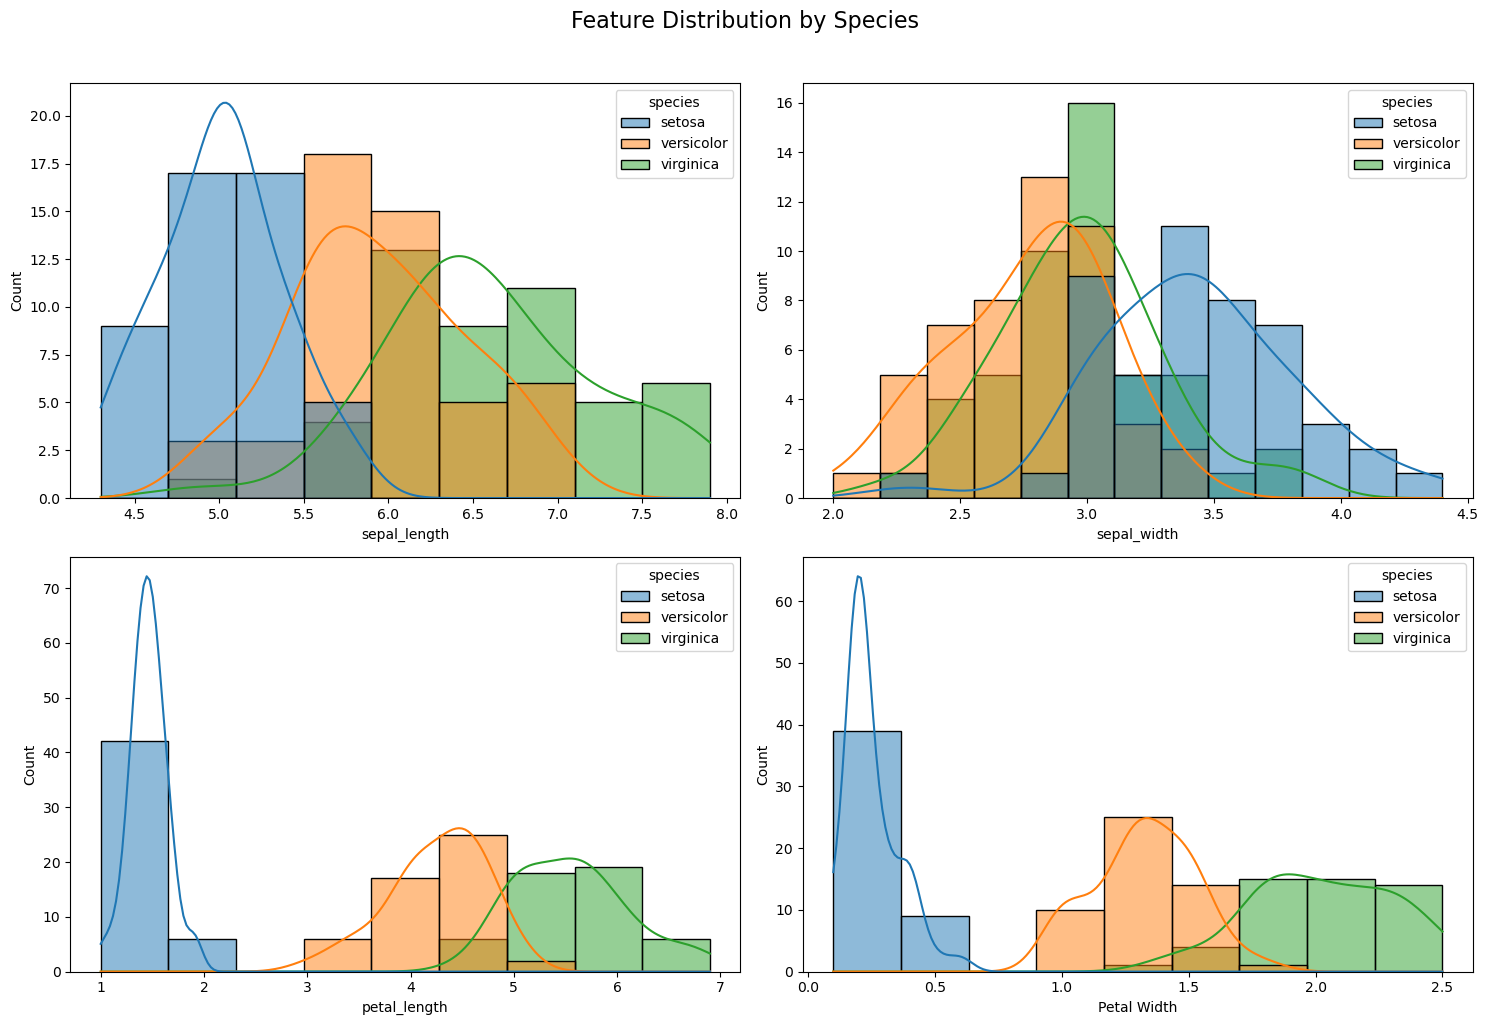

In [24]:
# get only the numeric columns
print('LIST OF COLUMNS')
numeric_cols = df_iris_clean.select_dtypes(include='number').columns.tolist()
print(numeric_cols)
# create a figure for each numeric field
fig, axes = plt.subplots(2, 2, figsize=(15,10))
# convert grid of axes to list
axes = axes.flatten()
# loop through each numeric column to create a distribution for each
for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df_iris_clean,
        x=col,
        hue='species',
        kde=True,
        ax=axes[i]
    )
#axes[i].set_title(f"Distribution of {col.replace('_', ' ').title()}")
axes[i].set_xlabel(col.replace('_', ' ').title())
axes[i].set_ylabel('Count')
plt.suptitle('Feature Distribution by Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('histograms_hue.png', dpi=150, bbox_inches='tight')
plt.show()

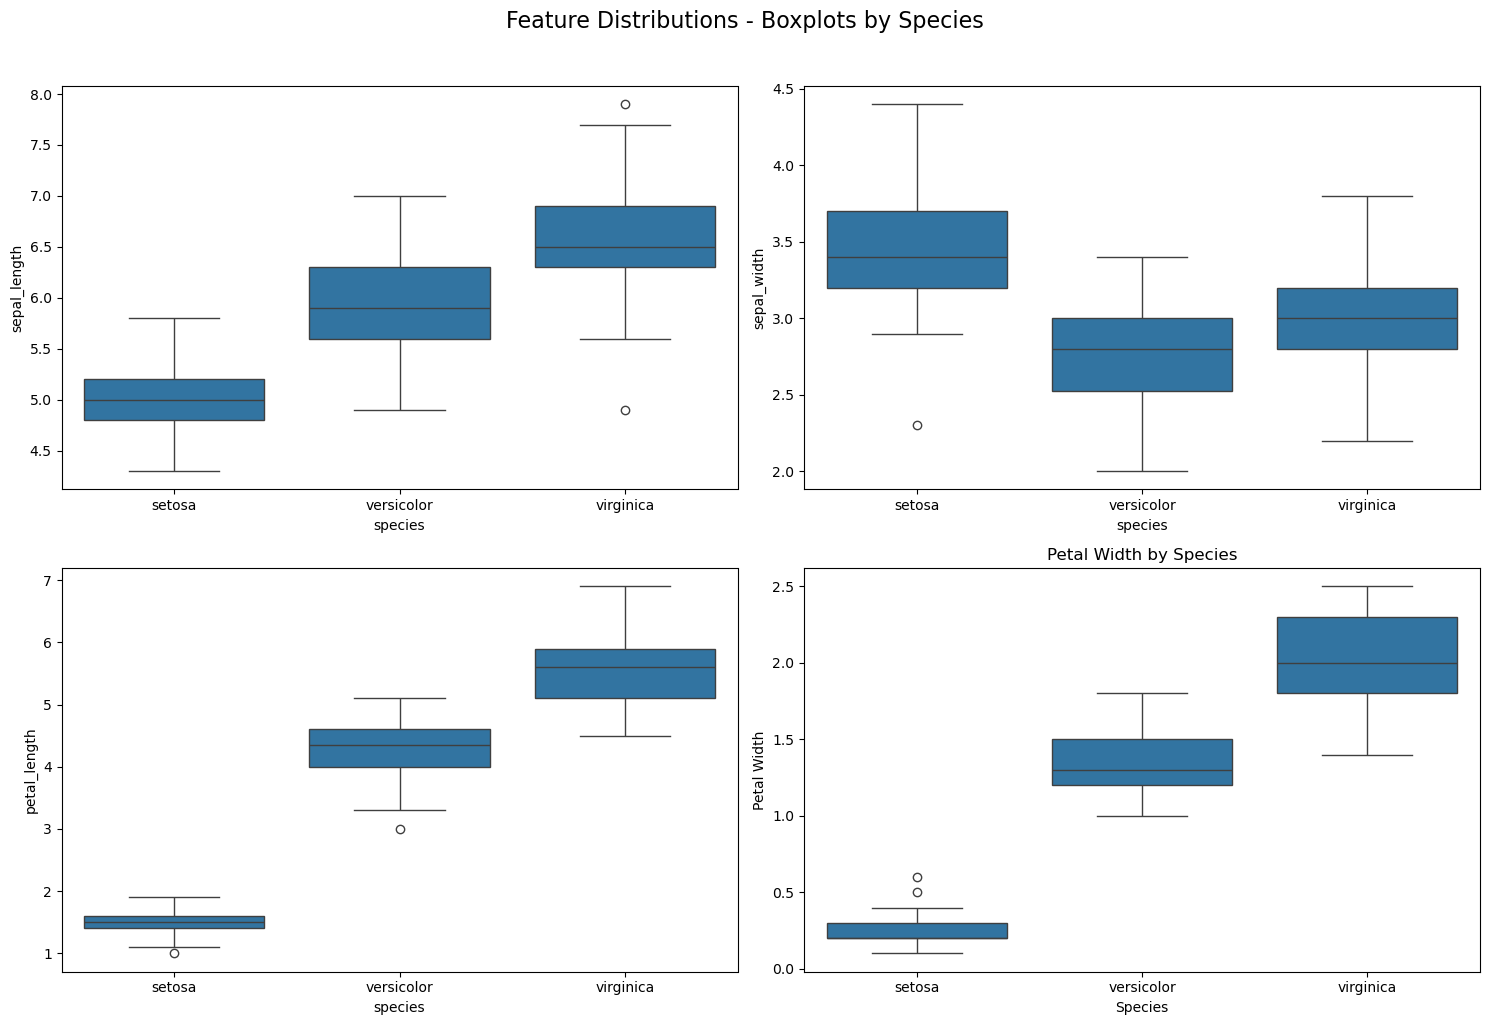

In [25]:
#Spotting Outliers
fig, axes = plt.subplots(2,2, figsize=(15,10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df_iris_clean,
        x='species',
        y=col,
        #palette='Set2',
        ax=axes[i]
    )
axes[i].set_title(f"{col.replace("_", " ").title()} by Species")
axes[i].set_xlabel('Species')
axes[i].set_ylabel(col.replace('_', ' ').title())

plt.suptitle('Feature Distributions - Boxplots by Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('Boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


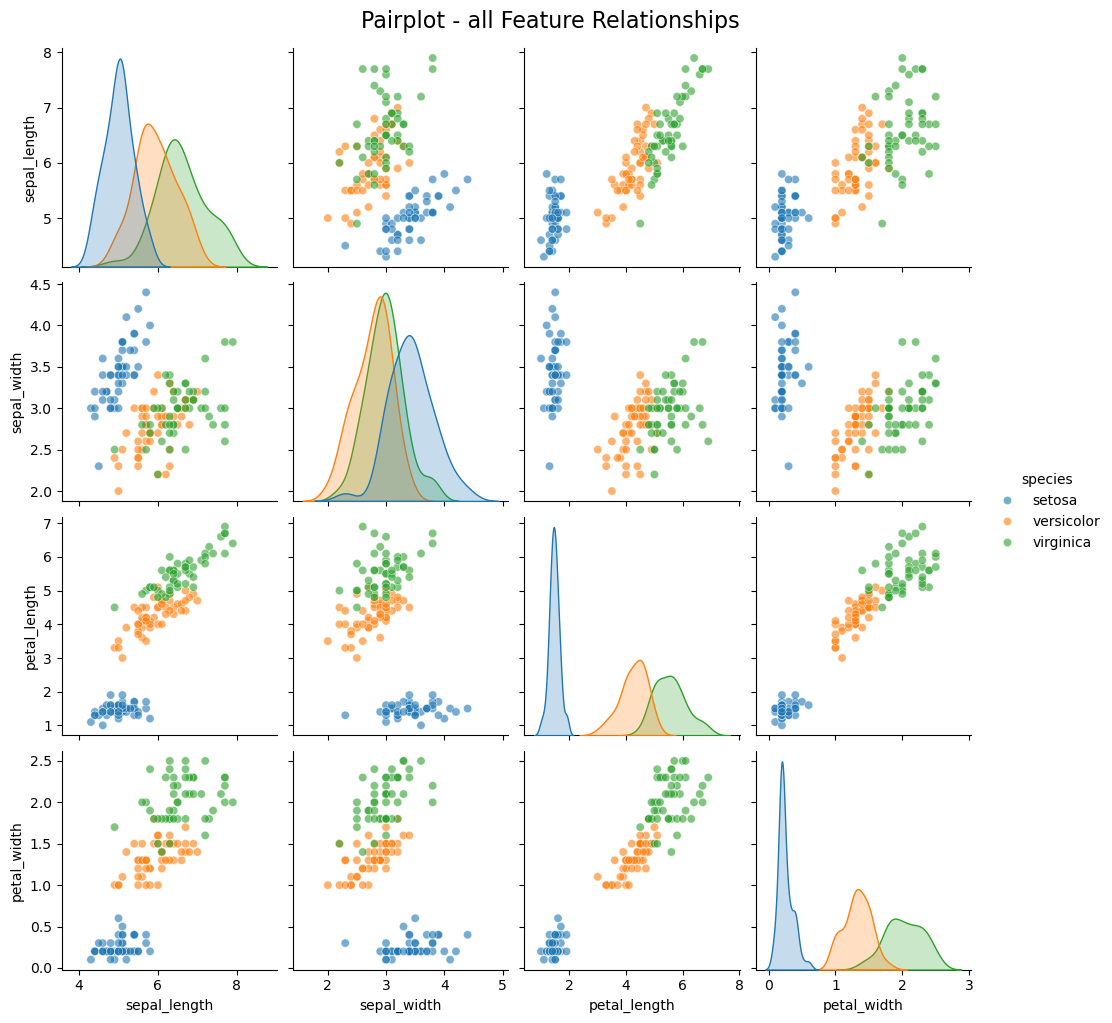

In [26]:
sns.pairplot(
    df_iris_clean,
    hue='species',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.suptitle('Pairplot - all Feature Relationships', y=1.02, fontsize=16)
plt.savefig('Pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

CORRELATION MATRIX:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


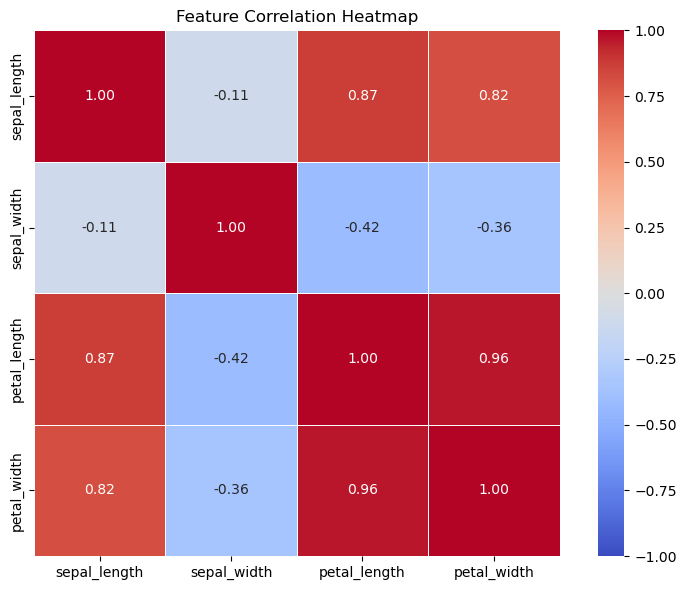

In [27]:
correlation_matrix = df_iris_clean.select_dtypes(include='number').corr()
print("CORRELATION MATRIX:")
display(correlation_matrix)

# visualize it as a heatmap
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidth=0.5,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ============================================================
# EDA FINDINGS SUMMARY
# ============================================================

print("""
KEY FINDINGS FROM EDA
=====================

1. SUMMARY STATISTICS
   - Petal measurements vary MORE than sepal measurements
   - Petal length ranges from 1.0 to 6.9 (huge range)
   - Sepal width ranges from 2.0 to 4.4 (smaller range)

2. SPECIES DIFFERENCES
   - Setosa has significantly smaller petals than the other two
   - Virginica has the largest measurements overall
   - Versicolor sits in the middle for most features

3. DISTRIBUTIONS
   - Setosa is clearly separated from the other two species
   - Versicolor and Virginica overlap more — harder to separate
   - Petal features separate species better than sepal features

4. CORRELATIONS
   - Petal length and petal width are highly correlated (~0.96)
   - Petal length and sepal length are also strongly correlated
   - Sepal width has weak or negative correlation with others

5. OUTLIERS
   - A few outliers visible in sepal width for setosa
   - Petal measurements are relatively clean
""")


KEY FINDINGS FROM EDA

1. SUMMARY STATISTICS
   - Petal measurements vary MORE than sepal measurements
   - Petal length ranges from 1.0 to 6.9 (huge range)
   - Sepal width ranges from 2.0 to 4.4 (smaller range)

2. SPECIES DIFFERENCES
   - Setosa has significantly smaller petals than the other two
   - Virginica has the largest measurements overall
   - Versicolor sits in the middle for most features

3. DISTRIBUTIONS
   - Setosa is clearly separated from the other two species
   - Versicolor and Virginica overlap more — harder to separate
   - Petal features separate species better than sepal features

4. CORRELATIONS
   - Petal length and petal width are highly correlated (~0.96)
   - Petal length and sepal length are also strongly correlated
   - Sepal width has weak or negative correlation with others

5. OUTLIERS
   - A few outliers visible in sepal width for setosa
   - Petal measurements are relatively clean

